МЕТОД BFGS
Функция: f(x1,x2) = 7x1² + 7x2² - 7x1 - 7x2
Стартовая точка: x0 = [1.0, 1.0]
Точность: ε = 0.001

Начальная матрица η_0 = [1.0 0.0; 0.0 1.0]
Начальный градиент ∇f_0 = [7.0, 7.0]

--------------------------------------------------
ШАГ 0
--------------------------------------------------
Текущая точка x           = [1.0, 1.0]
Градиент ∇f(x)            = [7.0, 7.0]
Норма градиента ||∇f(x)|| = 9.89949494
Условие остановки: 9.89949494 < 0.001 → НЕТ → продолжаем
Вектор направления p      = [-7.0, -7.0]
Найденный шаг α           = 0.07142857
Новая точка x_new         = [0.5, 0.5]
Новый градиент ∇f(x_new)  = [0.0, 0.0]
Δx = x_new - x            = [-0.5, -0.5]
Δg = ∇f_new - ∇f          = [-7.0, -7.0]
Коэффициент ρ             = 0.14285714
Обновлённая матрица η     = [0.53571429 -0.46428571; -0.46428571 0.53571429]

--------------------------------------------------
ШАГ 1
--------------------------------------------------
Текущая точка x           = [0.5, 0.5]
Градиент ∇f(x)          

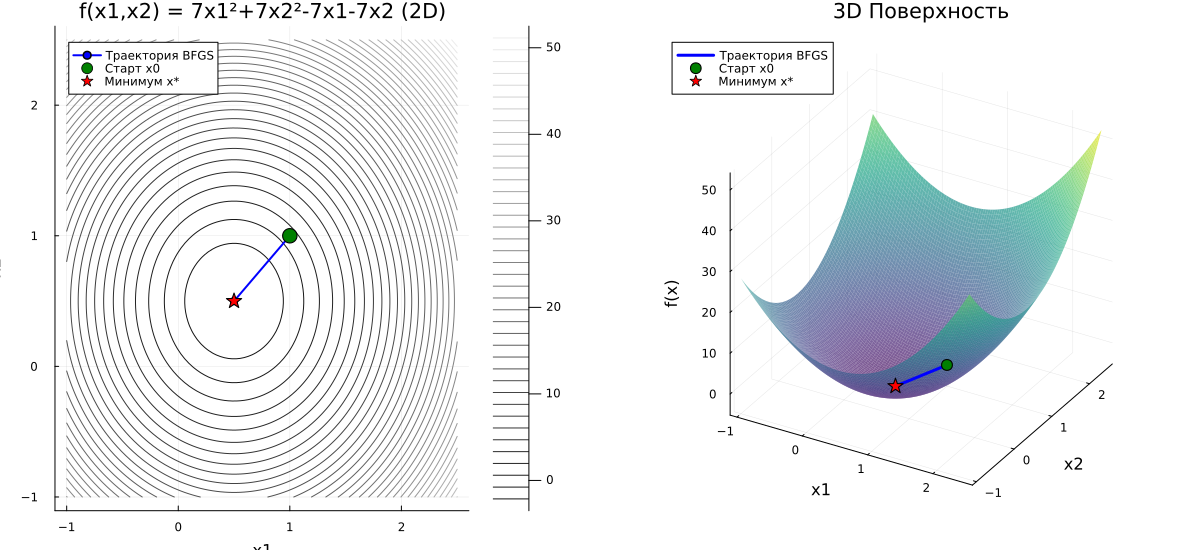

In [1]:
using LinearAlgebra
using Plots

gr()


function func(x)
    return 7*x[1]^2 + 7*x[2]^2 - 7*x[1] - 7*x[2]
end

function get_gradient(x)
    df_dx1 = 14*x[1] - 7
    df_dx2 = 14*x[2] - 7
    return [df_dx1, df_dx2]
end

function get_exact_alpha(p, grad)
    A = [14.0  0.0;
          0.0 14.0]
    alpha = -dot(p, grad) / dot(p, A * p)
    return alpha
end


function bfgs(f, x0; max_iters=100, epsilon=1e-3)
    x          = copy(x0)
    trajectory = [copy(x)]
    n          = length(x)

    println("=" ^ 60)
    println("МЕТОД BFGS")
    println("Функция: f(x1,x2) = 7x1² + 7x2² - 7x1 - 7x2")
    println("Стартовая точка: x0 = $x0")
    println("Точность: ε = $epsilon")
    println("=" ^ 60)

    H    = Matrix{Float64}(I, n, n)
    grad = get_gradient(x)

    println("\nНачальная матрица η_0 = $H")
    println("Начальный градиент ∇f_0 = $grad")

    iters = 0

    for i in 1:max_iters
        iters = i
        
        println("\n" * "-" ^ 50)
        println("ШАГ $(i - 1)")
        println("-" ^ 50)

        println("Текущая точка x           = $(round.(x,    digits=8))")
        println("Градиент ∇f(x)            = $(round.(grad, digits=8))")

        grad_norm = norm(grad)
        println("Норма градиента ||∇f(x)|| = $(round(grad_norm, digits=8))")
        print("Условие остановки: $(round(grad_norm, digits=8)) < $epsilon → ")

        if grad_norm < epsilon
            println("ДА → СТОП")
            break
        else
            println("НЕТ → продолжаем")
        end

        p     = -H * grad
        alpha = get_exact_alpha(p, grad)
        x_new = x + alpha * p

        println("Вектор направления p      = $(round.(p,     digits=8))")
        println("Найденный шаг α           = $(round(alpha,  digits=8))")
        println("Новая точка x_new         = $(round.(x_new, digits=8))")

        grad_new  = get_gradient(x_new)
        s         = x_new - x
        y         = grad_new - grad
        rho_denom = dot(y, s)

        println("Новый градиент ∇f(x_new)  = $(round.(grad_new, digits=8))")
        println("Δx = x_new - x            = $(round.(s,        digits=8))")
        println("Δg = ∇f_new - ∇f          = $(round.(y,        digits=8))")

        if abs(rho_denom) < 1e-12
            println("Знаменатель ρ слишком мал → СТОП")
            x    = x_new
            grad = grad_new
            push!(trajectory, copy(x))
            iters = i
            break
        end

        rho = 1.0 / rho_denom
        println("Коэффициент ρ             = $(round(rho, digits=8))")

        if isfinite(rho) && rho > 0
            I_n = Matrix{Float64}(I, n, n)
            H   = (I_n - rho * s * y') * H * (I_n - rho * y * s') + rho * s * s'
            println("Обновлённая матрица η     = $(round.(H, digits=8))")
        end

        x    = x_new
        grad = grad_new
        push!(trajectory, copy(x))
    end

    println("\n" * "=" ^ 60)
    println("ИТОГИ")
    println("=" ^ 60)
    println("Стартовая точка:               x0    = $x0")
    println("Найденный минимум:             x*    = $(round.(x, digits=8))")
    println("Значение функции в минимуме:   f(x*) = $(round(func(x), digits=8))")
    println("Количество итераций:           $iters")
    println("Количество точек в траектории: $(length(trajectory))")
    println("=" ^ 60)

    return x, trajectory, iters
end


function visualize_bfgs(f, x0, bounds_pad=1.5)
    x_opt, hist, _ = bfgs(f, x0)

    all_x1 = [p[1] for p in hist]
    all_x2 = [p[2] for p in hist]
    f_traj = [f(p)  for p in hist]

    xr = range(minimum(all_x1) - bounds_pad, maximum(all_x1) + bounds_pad, length=100)
    yr = range(minimum(all_x2) - bounds_pad, maximum(all_x2) + bounds_pad, length=100)
    Z  = [f([x, y]) for y in yr, x in xr]

    p1 = contour(xr, yr, Z,
        levels=40, color=:grays, fill=false,
        title="f(x1,x2) = 7x1²+7x2²-7x1-7x2 (2D)",
        xlabel="x1", ylabel="x2"
    )
    plot!(p1, all_x1, all_x2,
        color=:blue, lw=2, marker=:circle, markersize=4,
        label="Траектория BFGS"
    )
    scatter!(p1, [x0[1]],    [x0[2]],
        color=:green, markersize=8, marker=:circle, label="Старт x0"
    )
    scatter!(p1, [x_opt[1]], [x_opt[2]],
        color=:red, markersize=8, marker=:star5, label="Минимум x*"
    )

    p2 = surface(xr, yr, Z,
        color=:viridis, alpha=0.7, colorbar=false,
        title="3D Поверхность",
        xlabel="x1", ylabel="x2", zlabel="f(x)"
    )
    plot!(p2, all_x1, all_x2, f_traj,
        color=:blue, lw=3, label="Траектория BFGS"
    )
    scatter!(p2, [x0[1]],    [x0[2]],    [f(x0)],
        color=:green, markersize=6, label="Старт x0"
    )
    scatter!(p2, [x_opt[1]], [x_opt[2]], [f(x_opt)],
        color=:red, markersize=8, marker=:star5, label="Минимум x*"
    )

    display(plot(p1, p2, layout=(1, 2), size=(1200, 550)))
end


x0_test = [1.0, 1.0]
visualize_bfgs(x -> func(x), x0_test, 1.5)